In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid") # В 4 для графіків (охайний стиль)

# 0 Копіювання
pings = sns.load_dataset('penguins')
new = pings.copy()

print(new.describe())

# 1 Діагностика
print(new.head())
print(new.shape) # Розмір: (344, 7) 
print(new.info()) # Колонки: species, island, sex - str, bill_length_mm,
# bill_depth_mm, flipper_length_mm, body_mass_g - float64.
print(new.isna().sum()) # species, island - не мають незаповнених значень (не треба заповнювати/видаляти)
# Всі колонки, де треба число мають по 2 незаповнених значень (треба заповнити середнім або медіаною)
# Sex має найбільше число - 11 незаповнених, так як це текст, то треба модою заповнити
# Важливе доповнення: ці 2 особини й мають усі ці невідомі значення, які окрім species та island не мають інших даних, їх краще прибрати.
# Всі числові колонки в яких нема даних, це і є 2 пінгвіна, їх краще видалити



In [32]:
# 2 Заповнення/видалення невідомих значень
new = new.dropna(subset=['bill_length_mm']) # (Для себе) Цікаво! Незалежно від того, яку колонку видаляємо (для пінгвінів в яких нема значень), то видаляється увесь пінгвін, а не лише ця колонка для нього
print(f'Нова форма: {new.shape}')

mode_of_sex = new['sex'].mode()[0]
new['sex'] = new['sex'].fillna(mode_of_sex) # Пінгвіни невідомої статті були заповнені модою
# Заповнені модою, бо це текст (при чому бінарної вибірки, де є лише 2 опції - жіночої чи чоловічої статті)
print(new['sex'].isna().sum()) # Всі значення в цій колонці заповнені
print(new.duplicated().sum()) # Нема дублікатів
print(new.isna().sum().sum()) # В жодній з колонок нема пропусків

Нова форма: (342, 7)
0
0
0


In [ ]:
# 3 Додавання нових стовпчиків та інша специфічна інформація

new['body_mass_kg'] = new['body_mass_g'] / 1000 # вага в кілограмах
new['flipper_length_сm'] = new['flipper_length_mm'] / 10 # Довжина ласт в см
std_mass = new['body_mass_g'].std()
print(f'Стандартне відхилення маси: {std_mass:.1f} г')
print(f"Середня маса в грамах по видам: {new.groupby('species')['body_mass_g'].mean().round(1)}")
print(f'Які пінгвіни живуть на яких островах і скільки: {new.groupby('island')['species'].value_counts()}')


Стандартне відхилення маси: 802.0 г
Середня маса в грамах по видам: species
Adelie       3700.7
Chinstrap    3733.1
Gentoo       5076.0
Name: body_mass_g, dtype: float64
Які пінгвіни живуть на яких островах і скільки: island     species  
Biscoe     Gentoo       123
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        51
Name: count, dtype: int64


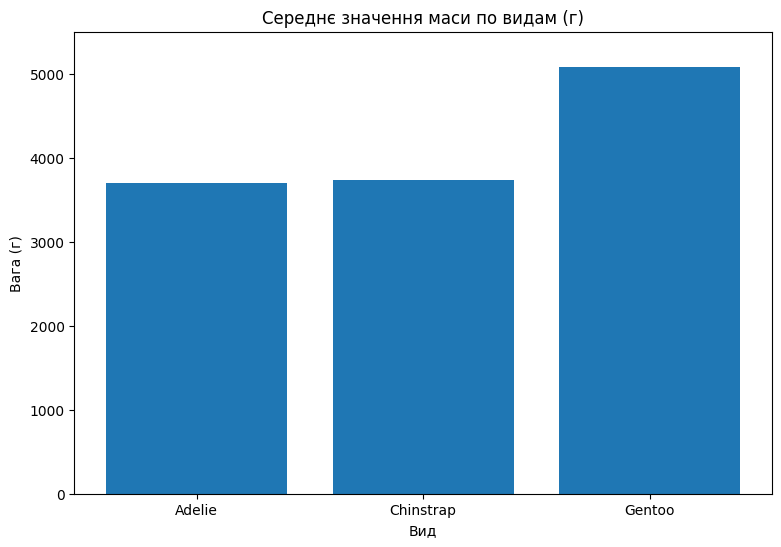

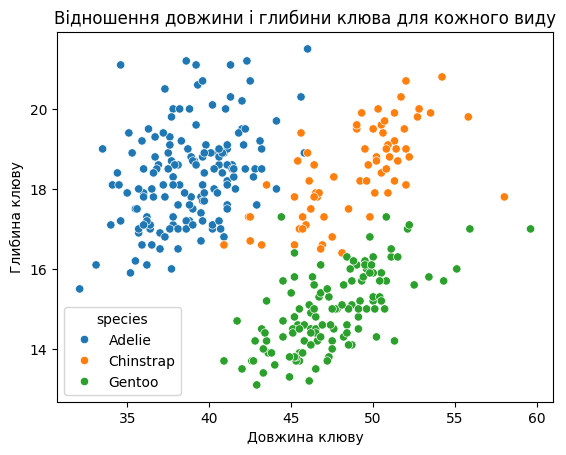

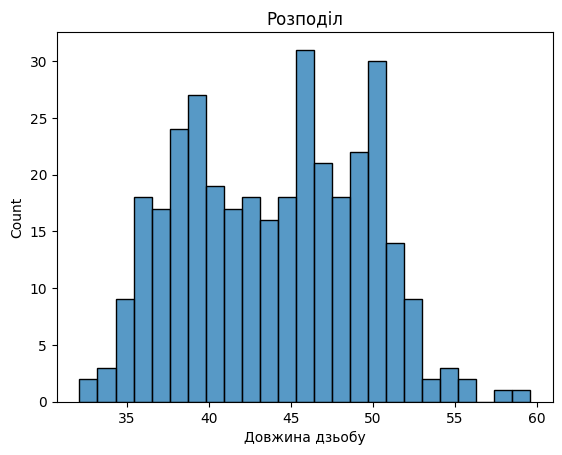

In [ ]:
# 4 Візуалізація
# 4.1 Середня маса по видах (bar, бо це метрика - середня вага, по категоріях)
middle_of_mass = new.groupby('species')['body_mass_g'].mean().round(1)
plt.figure(figsize=(9, 6)) # Відношення осей
plt.bar(middle_of_mass.index, middle_of_mass.values)
plt.title('Середнє значення маси по видам (г)') # Заголовок
plt.xlabel('Вид'); plt.ylabel('Вага (г)') # Назви осей
plt.ylim(0, 5500) # Межі для ваги (її мінімальні та максимальні значення)
plt.show()

# 4.2 Точковий, бо є співвідношення 2 числових метрик
sns.scatterplot(data=new, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.xlabel('Довжина клюву'); plt.ylabel('Глибина дзьобу')
plt.title("Відношення довжини і глибини дзьоба для кожного виду")
plt.show()

# 4.3 Гістограма, бо є лише одна метрика
sns.histplot(data=new, x='bill_length_mm', bins=25)
plt.title('Розподіл довжини дзьоба')
plt.xlabel('Довжина дзьобу'); plt.ylabel('Кількість')
plt.show()


5. Висновки

5.1. Всього 344 особини є частиною цієї популяції (2 з них не були враховані через відсутність даних про них). Статевий розподіл приблизно половина на половину.

5.2 Середня маса Adelie та Chinstrap приблизно рівна (~3700 грамів), Gentoo - навпаки мають середню масу в 5000г, що на 1300г більше за 2 інших вида.

5.3
Gentoo живуть лише на  острові Biscoe, Chinstrap — лишк на Dream, а Adelie — на всіх трьох островах.

5.4 
Середня довжина дзьобу - 45мм, з похибкою в +- 5мм.

5.5 
Стандартне відхилення від середнього значення маси пінгвінів становить 802 г (8,02 кг)